# **PART 1**

## Imporing libraries

In [44]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering




## Loading dataset & dropping identifier

In [45]:
df = pd.read_csv('../data/CC GENERAL.csv') 

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
df.head()

Shape: (8950, 18)

Columns:
 ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']

Dtypes:
 CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        floa

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [46]:
df = df.drop(columns=['CUST_ID'])

## Handling missing values

In [47]:
print(df.isnull().sum())
# Drop the single missing CREDIT_LIMIT row
df = df.dropna(subset=['CREDIT_LIMIT'])

# Impute MINIMUM_PAYMENTS with median
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

print("Missing values remaining:", df.isnull().sum().sum())

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64
Missing values remaining: 0


Checked for missing values using `df.isnull().sum()`. Two columns had missing data:
- **CREDIT_LIMIT:** 1 missing value, dropped that single row, since losing 1 out of 
  8950 customers has no meaningful effect on the analysis.
- **MINIMUM_PAYMENTS:** 313 missing values,imputed with the median rather than the 
  mean, because this column is a financial value likely skewed by a few customers 
  with very high minimum payments. The median is more robust to that kind of 
  skew/outliers than the mean would be.

After these two steps, `df.isnull().sum()` confirms 0 missing values remain.

## Scaling

In [48]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
print(scaled_data.shape)
print(scaled_data[:2])

(8949, 17)
[[-0.73205404 -0.24988139 -0.4249337  -0.35695651 -0.34911414 -0.4668054
  -0.80664908 -0.67871619 -0.70740935 -0.67529446 -0.47608293 -0.51138082
  -0.96037969 -0.52902627 -0.30242676 -0.52558844  0.36054128]
 [ 0.78685815  0.1340494  -0.4695839  -0.35695651 -0.45460688  2.6054375
  -1.22192823 -0.67871619 -0.91708951  0.57394905  0.11003155 -0.59184052
   0.68860056  0.81854607  0.0974534   0.2341587   0.36054128]]


Applied StandardScaler to all 17 features before clustering, which transforms each 
feature to have mean 0 and standard deviation 1.

Scaling is mandatory here because K-Means (and hierarchical clustering) group points 
based on Euclidean distance. Looking at the raw data, features like BALANCE and 
PAYMENTS are in the thousands, while features like PURCHASES_FREQUENCY and 
BALANCE_FREQUENCY range between 0 and 1. Without scaling, the distance calculation 
would be dominated almost entirely by the large-magnitude columns, and the 
frequency/ratio features, which are often just as informative for telling customers 
apart, would barely influence the clustering at all. Scaling puts every feature on 
equal footing regardless of its original unit.

## K-MEANS Clustering

In [49]:
inertia_values = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    inertia_values.append(km.inertia_)
    print(f"k={k}, inertia={km.inertia_:.2f}")

k=2, inertia=127772.93
k=3, inertia=111962.46
k=4, inertia=99054.06
k=5, inertia=91787.10
k=6, inertia=84819.87
k=7, inertia=79491.72
k=8, inertia=74455.54
k=9, inertia=69805.50
k=10, inertia=66433.78


## Elbow curve

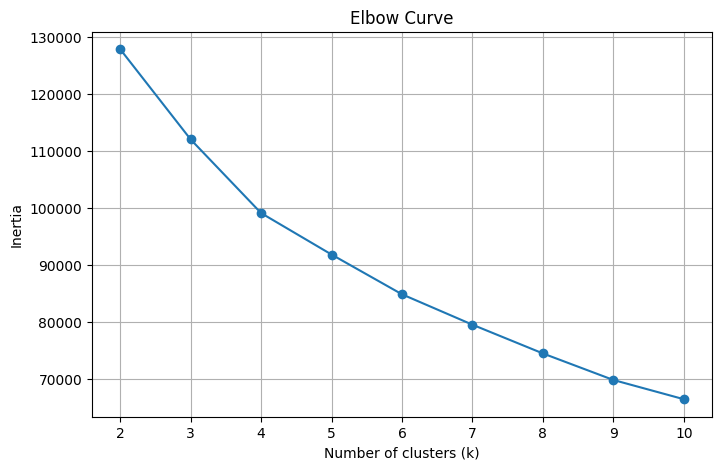

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia_values, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## Silhouette scores

In [51]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.2095
k=3, silhouette=0.2506
k=4, silhouette=0.1977
k=5, silhouette=0.1902
k=6, silhouette=0.2029
k=7, silhouette=0.2148
k=8, silhouette=0.2212
k=9, silhouette=0.2262
k=10, silhouette=0.2202


## Silhouette Score plot

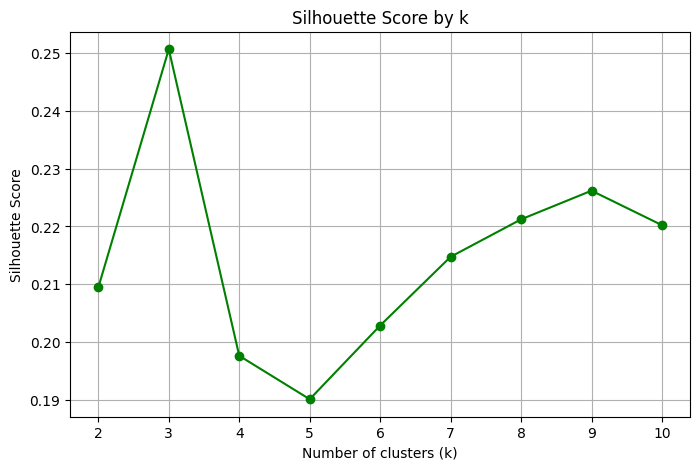

In [52]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

## **Choosing the optimal k**

The elbow curve shows inertia dropping sharply from k=2 to k=4, then flattening out,
the rate of decrease slows most noticeably after k=4 (drop of ~12,908 from k=3→4 vs. 
~7,267 from k=4→5), which is where the "elbow" sits.

The silhouette score tells a slightly different story: it peaks sharply at k=3 
(0.2506), drops at k=4-5, then climbs gradually again toward k=9 without beating k=3. 
So the two methods don't fully agree, silhouette technically favors k=3, while the 
elbow points to k=4.

Overall silhouette scores are fairly low across the board (all under 0.26), which 
suggests the clusters in this dataset aren't sharply separated, this makes sense for 
real customer behavior data, which tends to sit on a spectrum rather than form tight, 
distinct groups.

I chose k=4 for the final model: it's supported by the elbow method, its silhouette 
score (0.1977) is still reasonable relative to the range, and it produces enough 
segments to draw meaningful, distinct business interpretations (see Cluster 
Interpretation section below) without over-fragmenting the customer base.

## Fit K-Means with k=4

In [53]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(scaled_data)

print(df['Cluster'].value_counts())

Cluster
3    3977
1    3366
2    1197
0     409
Name: count, dtype: int64


## Heatmap

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        3551.153761           0.986879  7681.620098       5095.878826   
1         894.768927           0.934715  1236.263333        593.995933   
2        4602.449658           0.968389   501.862982        320.188797   
3        1012.995969           0.790134   270.281184        210.068828   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                   2587.208264    653.638891             0.946418   
1                    642.541696    209.816318             0.885255   
2                    181.759123   4521.509581             0.287832   
3                     60.479311    597.154288             0.170292   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                      

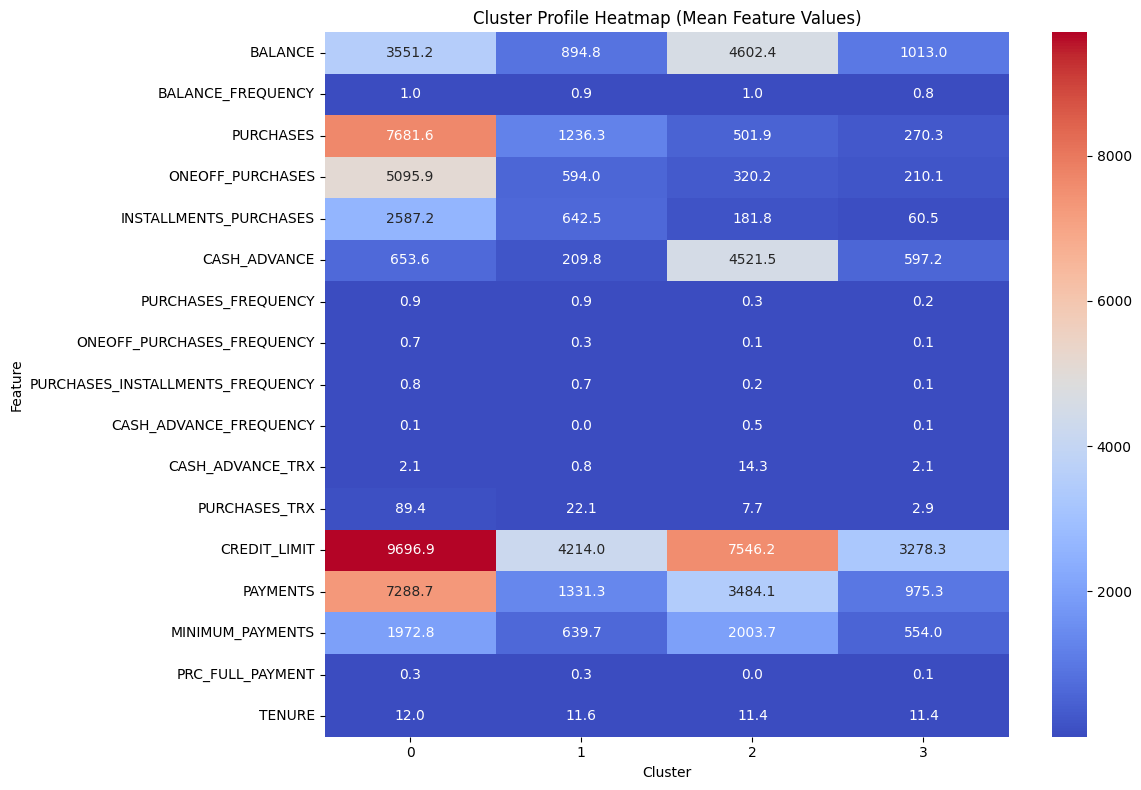

In [54]:
# Cluster Profiling
cluster_profile = df.groupby('Cluster').mean()
print(cluster_profile)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cluster_profile.T, annot=True, fmt='.1f', cmap='coolwarm', cbar=True)
plt.title('Cluster Profile Heatmap (Mean Feature Values)')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## **Cluster Interpretation**

- **Cluster 0 (409 customers), Premium spenders:** highest purchases and credit limits, 
  buy often, pay off a good chunk of what they owe. Most valuable customers.

- **Cluster 1 (3366 customers), Regular users:** moderate spending, high purchase 
  frequency, barely use cash advances. Largest "healthy" segment.

- **Cluster 2 (1197 customers), Cash advance users:** rarely buy things, but take cash 
  advances constantly and carry a high balance. Higher risk group for the bank.

- **Cluster 3 (3977 customers), Inactive/low engagement:** lowest activity across almost 
  every feature. Biggest group overall — candidates for a re-engagement campaign.

# **Part 2**

## Agglomerative Hierarchical

In [55]:
np.random.seed(42)
sample_indices = np.random.choice(scaled_data.shape[0], size=300, replace=False)
scaled_sample = scaled_data[sample_indices]

# Hierarchical clustering using Ward's method
linked = linkage(scaled_sample, method='ward')

## Dendrogram

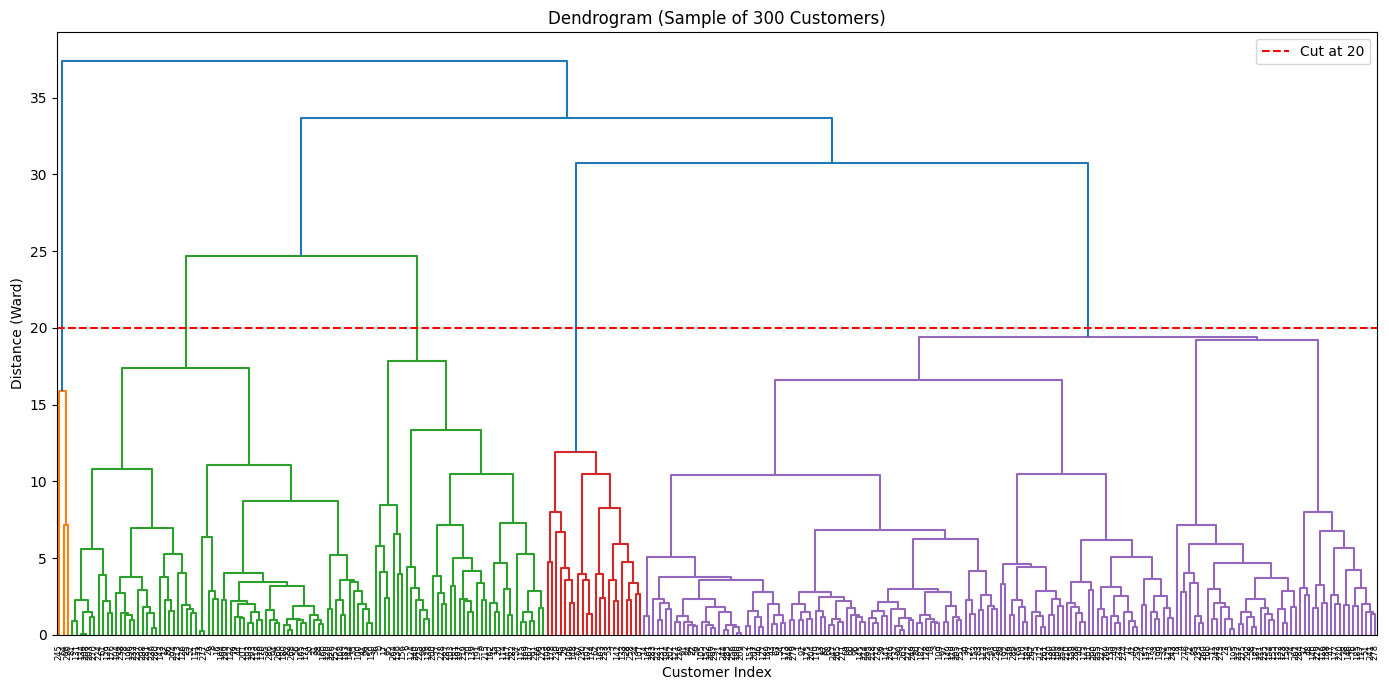

In [56]:
plt.figure(figsize=(14, 7))
dendrogram(linked, labels=None, leaf_rotation=90, leaf_font_size=6)

# Threshold line to show where we're cutting for k=4 clusters
threshold = 20 
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Cut at {threshold}')

plt.title('Dendrogram (Sample of 300 Customers)')
plt.xlabel('Customer Index')
plt.ylabel('Distance (Ward)')
plt.legend()
plt.tight_layout()
plt.show()

## Agglomerative Clustering with n=4

In [57]:
agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg_cluster.fit_predict(scaled_sample)

print(pd.Series(agg_labels).value_counts())

2    167
0    108
3     22
1      3
Name: count, dtype: int64


## Comparison of Hierarchical Clustering with K-Means

In [58]:
kmeans_sample_labels = kmeans_final.labels_[sample_indices]

comparison = pd.crosstab(kmeans_sample_labels, agg_labels,
                          rownames=['KMeans'], colnames=['Hierarchical'])
print(comparison)

Hierarchical   0  1    2   3
KMeans                      
0             10  3    0   0
1             85  0   30   1
2              3  0   14  21
3             10  0  123   0


## **Comparison Report**

- **Agreement:** Both methods clearly separate cash-advance-heavy customers and identify 
  a large low-activity segment, the two most distinct behavioral groups.
- **Disagreement:** Hierarchical clustering blurs the line between "regular transactors" 
  and "low-activity" customers, while K-Means keeps them separate. Hierarchical also 
  splits off a very small sub-cluster of premium spenders rather than treating them 
  as one group.
- **Interpretability:** K-Means is easier to interpret directly, every customer gets one 
  clean label from a single pass. Hierarchical clustering is more useful for exploring 
  structure (the dendrogram shows how clusters nest and merge), but reading business 
  meaning off it takes more manual judgment.
- **Recommendation:** For a real business use case, K-Means is the better choice, it 
  scales to the full ~9000 customers (hierarchical only ran on a 300-row sample due 
  to computational cost), produces more consistent, evenly-sized segments, and is 
  simpler to explain to non-technical stakeholders like marketing or risk teams.